### Version 2 - using multiline plots and normalization for comparing trends with different value ranges

**The first part of this notebook is practically identical to the version from lecture 7, see further below for the multiline/normalization approach.**

In [210]:
import pandas as pd
import seaborn as sns
import numpy as np

In [211]:
df = pd.read_csv("ricebeefcoffee.csv")
df

,Year,Month,Price_beef_kilo,Price_rice_kilo,Price_coffee_kilo,Inflation_rate,Price_rice_infl,Price_beef_infl,Price_coffee_infl
0,1992,Feb,2.52,0.28,1.51,89.59,0.53,4.78,2.86
1,1992,Mar,2.45,0.28,1.55,89.59,0.53,4.64,2.94
2,1992,Apr,2.38,0.28,1.45,89.59,0.53,4.51,2.75
3,1992,May,2.38,0.27,1.34,89.59,0.51,4.51,2.54
4,1992,Jun,2.33,0.27,1.30,89.59,0.51,4.42,2.46
...,...,...,...,...,...,...,...,...,...
355,2021,Sep,5.66,0.40,4.97,-1.29,0.39,5.59,4.91
356,2021,Oct,5.70,0.40,5.31,-1.29,0.39,5.63,5.24
357,2021,Nov,5.95,0.40,5.71,-1.29,0.39,5.87,5.64
358,2021,Dec,5.95,0.40,5.91,-1.29,0.39,5.87,5.83


In [212]:
df.columns

Index(['Year', 'Month', 'Price_beef_kilo', 'Price_rice_kilo',
       'Price_coffee_kilo', 'Inflation_rate', 'Price_rice_infl',
       'Price_beef_infl', 'Price_coffee_infl'],
      dtype='str')

In [213]:
# filter out only some relevant data for not
# we'll use the inflation adjusted versions of hte prices
# SO THAT THEY ARE COMPARABLE
df = df.drop(['Price_beef_kilo', 'Price_rice_kilo', 'Price_coffee_kilo', 'Inflation_rate'], axis=1)


In [214]:
df

,Year,Month,Price_rice_infl,Price_beef_infl,Price_coffee_infl
0,1992,Feb,0.53,4.78,2.86
1,1992,Mar,0.53,4.64,2.94
2,1992,Apr,0.53,4.51,2.75
3,1992,May,0.51,4.51,2.54
4,1992,Jun,0.51,4.42,2.46
...,...,...,...,...,...
355,2021,Sep,0.39,5.59,4.91
356,2021,Oct,0.39,5.63,5.24
357,2021,Nov,0.39,5.87,5.64
358,2021,Dec,0.39,5.87,5.83


### Many ways to study a dataset like this, let's compare by the year first

In [215]:
df = df.drop("Month", axis=1)

In [216]:
df = df.groupby("Year").mean().dropna()
df

,Price_rice_infl,Price_beef_infl,Price_coffee_infl
Year,,,
1992,0.506364,4.633636,2.639091
1993,0.435000,4.820000,2.873333
1994,0.479167,4.185833,5.938333
1995,0.561667,3.260833,5.817500
1996,0.577500,2.968333,4.570833
1997,0.501667,3.063333,6.906667
1998,0.497500,2.801667,4.867500
1999,0.397500,2.890833,3.657500
2000,0.312500,2.975000,2.969167


<Axes: >

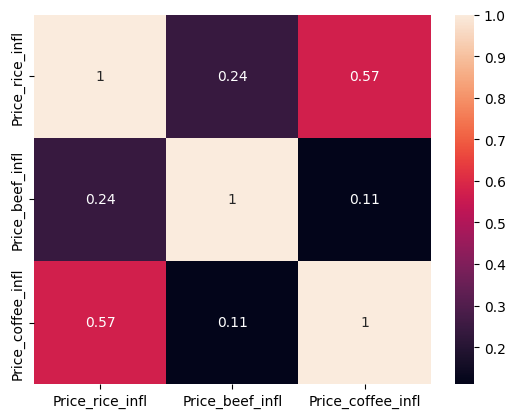

In [217]:
correlations = df.corr(numeric_only=True)
sns.heatmap(correlations, annot=True)

<Axes: ylabel='Year'>

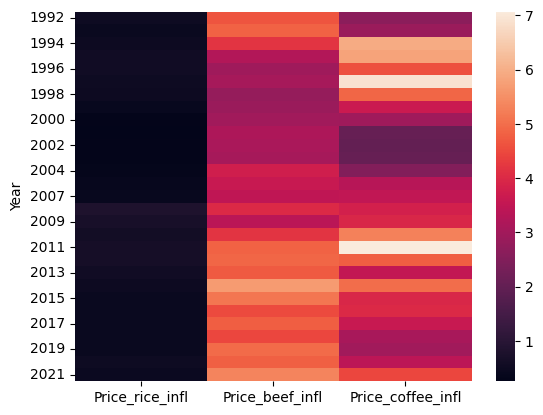

In [218]:
sns.heatmap(df)

You can Google/AI (based on the heatmap above) => coffee price 2011, coffee price 1997, rice price 2008, you should find information what happened in those dates / products.

### Reload the data and try something else

In [219]:
df = pd.read_csv("ricebeefcoffee.csv")
df = df.drop(['Price_beef_kilo', 'Price_rice_kilo', 'Price_coffee_kilo', 'Inflation_rate'], axis=1)
df

,Year,Month,Price_rice_infl,Price_beef_infl,Price_coffee_infl
0,1992,Feb,0.53,4.78,2.86
1,1992,Mar,0.53,4.64,2.94
2,1992,Apr,0.53,4.51,2.75
3,1992,May,0.51,4.51,2.54
4,1992,Jun,0.51,4.42,2.46
...,...,...,...,...,...
355,2021,Sep,0.39,5.59,4.91
356,2021,Oct,0.39,5.63,5.24
357,2021,Nov,0.39,5.87,5.64
358,2021,Dec,0.39,5.87,5.83


In [220]:
# asked from ChatGPT, prompt:
# I have a month column in a pandas dataframe, in "Jan", "Feb" etc. format, 
# I wish to convert into numeric integer format

# Mapping month abbreviations to integers
month_mapping = {
    'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6,
    'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12
}

# Convert the 'Month' column to numeric
df['Month'] = df['Month'].map(month_mapping)

In [221]:
df

,Year,Month,Price_rice_infl,Price_beef_infl,Price_coffee_infl
0,1992,2,0.53,4.78,2.86
1,1992,3,0.53,4.64,2.94
2,1992,4,0.53,4.51,2.75
3,1992,5,0.51,4.51,2.54
4,1992,6,0.51,4.42,2.46
...,...,...,...,...,...
355,2021,9,0.39,5.59,4.91
356,2021,10,0.39,5.63,5.24
357,2021,11,0.39,5.87,5.64
358,2021,12,0.39,5.87,5.83


<Axes: xlabel='Year', ylabel='Month'>

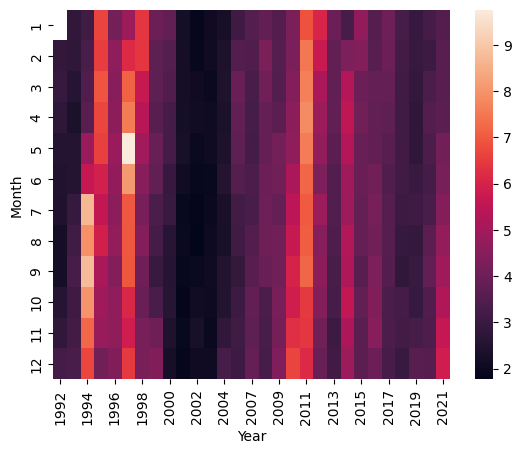

In [222]:
# we can see high spots in 1997 May and couple of these in 1994 too
df_pivot = df.pivot_table(index="Month", columns="Year", values="Price_coffee_infl")
sns.heatmap(df_pivot)

<Axes: xlabel='Year', ylabel='Month'>

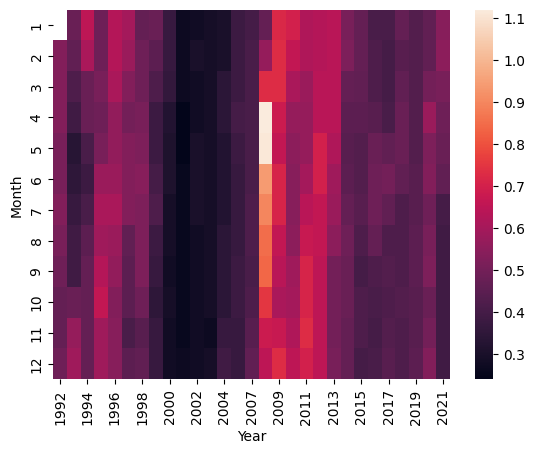

In [223]:
# 2008 "rice crisis", Google it
df_pivot = df.pivot_table(index="Month", columns="Year", values="Price_rice_infl")
sns.heatmap(df_pivot)

<Axes: xlabel='Year', ylabel='Month'>

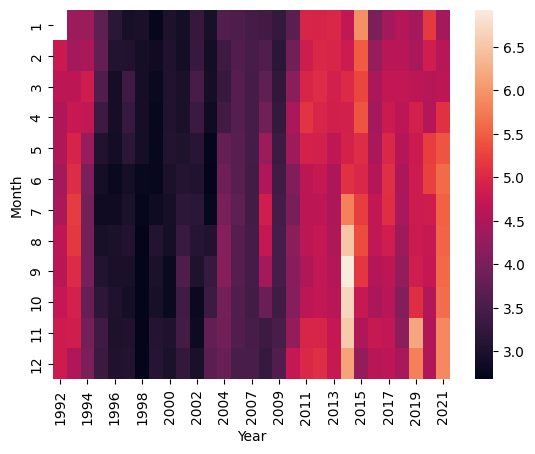

In [224]:
# 2008 "rice crisis", Google it
df_pivot = df.pivot_table(index="Month", columns="Year", values="Price_beef_infl")
sns.heatmap(df_pivot)

### Multiline plots + normalization

In [225]:
# flights-data as example
flights = sns.load_dataset("flights")

In [226]:
# in order to use multiline plot with hue
# we can only have three variables
# x, y and the hue variable
flights.head(3)

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132


<Axes: xlabel='year', ylabel='passengers'>

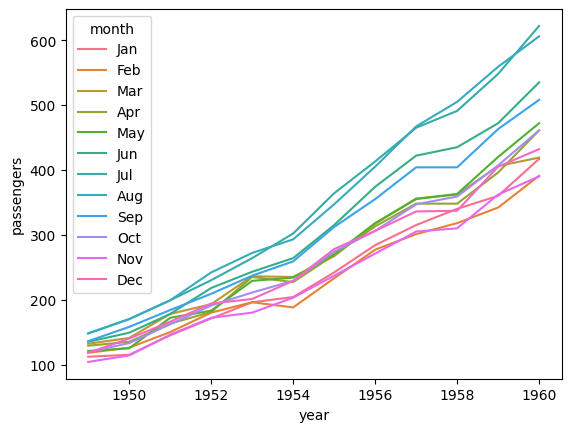

In [227]:
# from seaborn documentation:
# this can be modified so that we can actually compare the three products too
# beef, rice and coffee
sns.lineplot(data=flights, x="year", y="passengers", hue="month")

### Let's get a similar line plot with the rice-beef-coffee -dataset

In [228]:
# we should only have one x-value, one y-value + the hue-value (three variables in total)
df.head()

,Year,Month,Price_rice_infl,Price_beef_infl,Price_coffee_infl
0,1992,2,0.53,4.78,2.86
1,1992,3,0.53,4.64,2.94
2,1992,4,0.53,4.51,2.75
3,1992,5,0.51,4.51,2.54
4,1992,6,0.51,4.42,2.46


In [229]:
# a small trick, combine year + month as a decimal => float
# this is now a functional x-axis for our needs
df['YearMonth'] = df['Year'].astype(str) + "." + df['Month'].astype(str)
df['YearMonth'] = df['YearMonth'].astype(float)

In [230]:
# let's see current version
df.head()

,Year,Month,Price_rice_infl,Price_beef_infl,Price_coffee_infl,YearMonth
0,1992,2,0.53,4.78,2.86,1992.2
1,1992,3,0.53,4.64,2.94,1992.3
2,1992,4,0.53,4.51,2.75,1992.4
3,1992,5,0.51,4.51,2.54,1992.5
4,1992,6,0.51,4.42,2.46,1992.6


In [231]:
# we can now drop the original year and month
df = df.drop(['Year', 'Month'], axis=1)

In [232]:
# x-axis is now good, we can now start processing the product columns
df.head()

,Price_rice_infl,Price_beef_infl,Price_coffee_infl,YearMonth
0,0.53,4.78,2.86,1992.2
1,0.53,4.64,2.94,1992.3
2,0.53,4.51,2.75,1992.4
3,0.51,4.51,2.54,1992.5
4,0.51,4.42,2.46,1992.6


In [233]:
# melt the DataFrame so it's similar to the flights-data
df_melt = pd.melt(df, id_vars=['YearMonth'], value_vars=['Price_rice_infl', 'Price_beef_infl', 'Price_coffee_infl'],
                  var_name="Product", value_name="PriceInfl")

In [234]:
df_melt.head()

,YearMonth,Product,PriceInfl
0,1992.2,Price_rice_infl,0.53
1,1992.3,Price_rice_infl,0.53
2,1992.4,Price_rice_infl,0.53
3,1992.5,Price_rice_infl,0.51
4,1992.6,Price_rice_infl,0.51


In [235]:
df_melt.isna().sum()

YearMonth     0
Product       0
PriceInfl    39
dtype: int64

In [236]:
df_melt = df_melt.dropna()

<Axes: xlabel='YearMonth', ylabel='PriceInfl'>

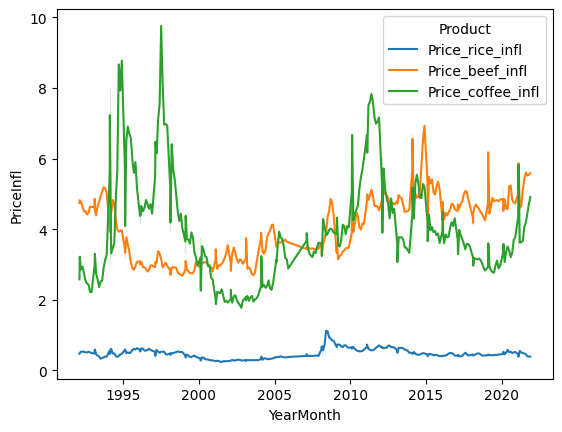

In [237]:
sns.lineplot(data=df_melt, x="YearMonth", y="PriceInfl", hue="Product")

**This is pretty good already, but since rice is so much cheaper than beef/coffee, it's hard to compare the actual trends.**

### To further inspect these trends, we can NORMALIZE the values

In [238]:
# NORMALIZATION = scale all values between 0.0 and 1.0
# 1.0 = highest original value
# 0.0 = lowest original value
# any other decimals are between these two values

# copy the original DataFrame
normalized_df = df.copy()

# MinMax-normalization
normalized_df = (normalized_df - normalized_df.min()) / (normalized_df.max() - normalized_df.min())

In [239]:
normalized_df

,Price_rice_infl,Price_beef_infl,Price_coffee_infl,YearMonth
0,0.329545,0.494118,0.136421,0.003333
1,0.329545,0.461176,0.146433,0.006667
2,0.329545,0.430588,0.122653,0.010000
3,0.306818,0.430588,0.096370,0.013333
4,0.306818,0.409412,0.086358,0.016667
...,...,...,...,...
355,0.170455,0.684706,0.392991,0.993333
356,0.170455,0.694118,0.434293,0.966667
357,0.170455,0.750588,0.484355,0.967000
358,0.170455,0.750588,0.508135,0.967333


In [240]:
# melt the DataFrame so it's similar to the flights-data
normalized_df_melt = pd.melt(normalized_df, id_vars=['YearMonth'], value_vars=['Price_rice_infl', 'Price_beef_infl', 'Price_coffee_infl'],
                  var_name="Product", value_name="PriceInfl")

<Axes: xlabel='YearMonth', ylabel='PriceInfl'>

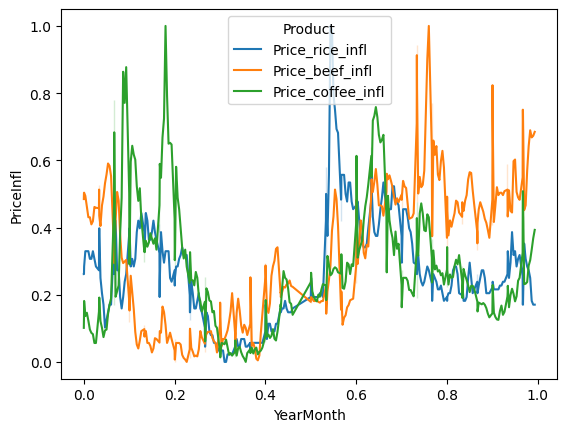

In [241]:
sns.lineplot(data=normalized_df_melt, x="YearMonth", y="PriceInfl", hue="Product")

**Now we can actually compare the trends!**

In [ ]:
# it seems coffee/rice follow similar trends, but beef has the opposite trend?
# however, between 2000-2010, the trends are more or lress synchronized
# probably have to study a bit more (Google/GenAI) if these trends can be explained
